# Training Quadruped Locomotion in Ant-v5 moving
- Name: John Song
- Course: EE5329
- Term: Spring2026

## 1.0 Task definition

#### 1.1 Environment : Ant-v5  (https://gymnasium.farama.org/environments/mujoco/ant/)
- The ant is a 3D quadruped robot consisting of a torso (free rotational body) with four legs attached to it, where each leg has two body parts.
- 4 legs and 1 body (8 joints)

#### 1.2 Goals    
- To coordinate the four legs to move in the forward (right) direction by applying torque to the eight hinges connecting the two body parts of each leg and the torso.

#### 1.3 Observation
- A 27-dimentional continuous vector containing the torso's 3D position and oreitantion, alongside the angles and celocities of its 8 leg joints `Observation space: Box(-inf, inf, (105,), float64)`. 

#### 1.4 Action  
- An 8-dimensional continuous vector with value between [-1,1], representing the precise motor torque applied to each of the 8 hinge joints `Action space shape: (8,)`.
- `Action Input Sample: [-0.7540165   0.88591754 -0.78097594  0.38984188 -0.946787   -0.08350106
 -0.8810074  -0.62489676]`


#### 1.5 Reward (https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/ant_v5.py)

$$\text{Reward} = \text{healthy\_reward} + \text{forward\_reward} - \text{ctrl\_cost} - \text{contact\_cost}$$


1. *Healthy Reward*:
   - Initial Setup:  
     ```python
     healthy_reward: float = 1.0
     healthy_z_range: tuple[float, float] = (0.2, 1.0)
     ```
   - Condition:  
     If the Ant is within the healthy Z-range, it is considered healthy. The reward is applied only if `self.is_healthy` is `True`.
   - Calculation:  
     ```python
     self.is_healthy * self._healthy_reward
     ```

2. *Forward Reward*:
   - Initial Setup:  
     ```python
     forward_reward_weight: float = 1.0
     ```
   - Calculation:  
     The forward reward is based on the Ant's velocity in the x-direction (`x_velocity`), weighted by `forward_reward_weight`.
     ```python
     forward_reward = x_velocity * self._forward_reward_weight
     ```

3. *Control Cost*:
   - Initial Setup:  
     ```python
     ctrl_cost_weight: float = 0.5
     ```
   - Calculation:  
     The control cost penalizes large actions. It's computed as the sum of the squared actions, scaled by `ctrl_cost_weight`.
     ```python
     ctrl_cost = self._ctrl_cost_weight * np.sum(np.square(action))
     ```

4. *Contact Cost*:
   - Initial Setup:  
     ```python
     contact_cost_weight: float = 5e-4
     contact_force_range: tuple[float, float] = (-1.0, 1.0)
     ```
   - Calculation:  
     The contact cost penalizes the agent for excessive external contact forces. These forces are clipped within `contact_force_range` before being squared and summed. The resulting value is then scaled by `contact_cost_weight`.
     ```python
     contact_cost = self._contact_cost_weight * np.sum(np.square(self.contact_forces))
     ```

#### 1.6 Episode End 
- Terminated early if the Ant crashes ($Z_{height}$ < $0.2$). Truncated successfully if the agent survives the maximun limit $< 1,000$ timesteps

#### Why this task is interesting: 
At its core, this project presents a 3D environment where the task is to move a simulated agent (the Ant) forward, with the reward structure closely tied to both contact forces and velocity. The dynamics of balancing movement while minimizing external forces (e.g., contact with the ground) mirror real-world challenges in robotics, particularly in the context of legged locomotion.


In [3]:
import gymnasium as gym
import matplotlib.pyplot as plt

Environment: Ant-v5
Observation space: Box(-inf, inf, (105,), float64)
Action space: Box(-1.0, 1.0, (8,), float32)
Action space shape: (8,)
Action space bounds: [[-1. -1. -1. -1. -1. -1. -1. -1.], [1. 1. 1. 1. 1. 1. 1. 1.]]
----------------------------------------------------------------------------------------------
Action Input Sample: [-0.10146523  0.4567337   0.93321437 -0.9764312   0.86441875 -0.2206107
 -0.40843564  0.6771444 ]
----------------------------------------------------------------------------------------------
Image for Ant-v5:


(np.float64(-0.5), np.float64(479.5), np.float64(479.5), np.float64(-0.5))

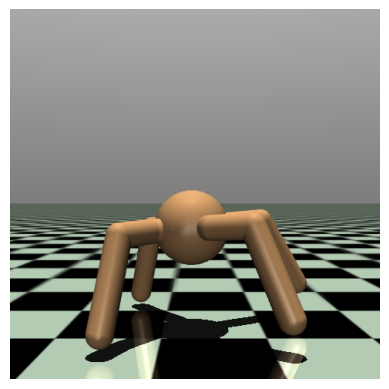

In [4]:
env_name = "Ant-v5"
env = gym.make(env_name, render_mode="rgb_array")

print(f"Environment: {env_name}")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Action space shape: {env.action_space.shape}")
print(f"Action space bounds: [{env.action_space.low}, {env.action_space.high}]")
print(f"----------------------------------------------------------------------------------------------")
action = env.action_space.sample()
print(f"Action Input Sample: {action}")
print(f"----------------------------------------------------------------------------------------------")
print("Image for Ant-v5:")
obs, _ = env.reset()
for _ in range(10):
    obs, *_ = env.step(env.action_space.sample())
frame = env.render()
plt.imshow(frame)
plt.axis("off")

In [5]:
print(f"----------------------------------------------------------------------------------------------")
print("Example for Observeration, Reward, Information: ")
base = env.unwrapped
base.step(env.action_space.sample())

----------------------------------------------------------------------------------------------
Example for Observeration, Reward, Information: 


(array([ 6.74741067e-01,  9.78968166e-01, -1.54098407e-02, -6.04375249e-02,
        -1.94245133e-01,  2.47565278e-01,  6.69669604e-01,  6.29852186e-01,
        -9.63310038e-01,  1.90129681e-01, -1.22344704e+00,  5.24907927e-01,
         1.07585831e+00,  1.30971593e+00, -7.26668780e-01,  1.80819986e-01,
        -1.39771085e+00, -5.03162569e-01,  3.43181758e-01,  3.24136796e+00,
        -9.36503911e+00, -1.95592491e+00,  6.17024246e+00, -5.94742213e+00,
        -1.56009048e-02, -5.94632968e-03, -4.37521440e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.0

## 2.0 Baseline Setup

### 2.1 Algorighm
- PPO (Proximal Policy Optimization)
- A2C (Advantage Actor-Critic)
- DDPG (Deep Deterministic Policy Gradient)
- SAC (Soft Actor-Critic)

### 2.2 hyperparameters


#### 2.2.1 PPO
- learning_rate=0.0003,
- n_steps=2048,
- batch_size=64,
- n_epochs=10,
- gamma=0.99,
- gae_lambda=0.95,
- clip_range=0.2,


#### 2.2.2 A2C  
- learning_rate=0.0003,
- n_steps=5,
- gamma=0.99,
- gae_lambda=0.95,

#### 2.2.3 DDPG 
- learning_rate=0.001, (0.002 for critic)
- buffer_size=2000,
- learning_starts=100,
- batch_size=100,
- tau=0.005,
- gamma=0.98,

#### 2.2.4 SAC  
- learning_rate=0.0003,
- buffer_size=300000,
- learning_starts=100,
- batch_size=256,
- tau=0.005,
- gamma=0.99,
- train_freq=1,
- gradient_steps=1,

### 2.3 Software

In [6]:
import sys
import gymnasium
import torch 
import stable_baselines3 as sb3
print(f"Python version: {sys.version}")
print(f"Gymnasium verison: {gymnasium.__version__}")
print(f"Stable-Baselines3: {sb3.__version__}")
print(f"Torch version: {torch.__version__}")

Python version: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
Gymnasium verison: 1.2.3
Stable-Baselines3: 2.8.0
Torch version: 2.11.0+cu130


### 2.4 Random Seed 
- Environment seed = 42 (trained parallel with 4 environments [42,43,44,45])
- Algorithm seed = 42 

### 2.5 File structure

## 3. Experiment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

### 3.1 Experiment A (baseline_Preliminary study):
- Comparing Random Agent with **PPO** Agent baseline
- Base on PPO, change `total timesteps`
- PPO Agent is running with $1000,000$ vs. $4000,000$ timesteps, which $1000$ vs. $4000$ epsoides
- seed is random generate by system

In [2]:
def learning_curve(log_dir, title):
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    scalars = ea.Scalars("rollout/ep_rew_mean")
    steps=[s.step for s in scalars]
    values = [s.value for s in scalars]
    plt.plot(steps,values)
    plt.title(f"{title} Learning Curve")
    plt.xlabel("Timesteps")
    plt.ylabel("Epiodes Reward")
    plt.grid(True, alpha=0.3)
    plt.show()

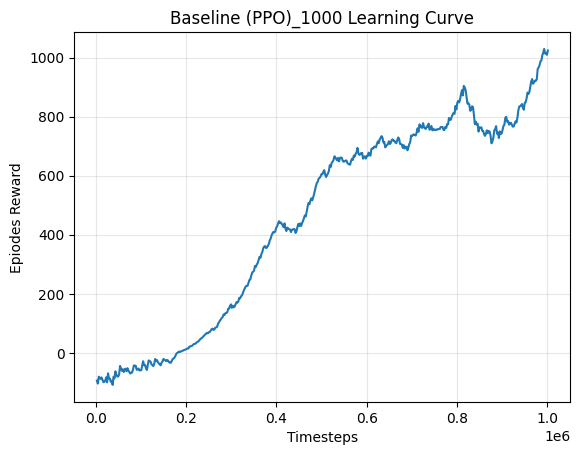

In [103]:
log_dir = "./graph/Baseline_1000/"
title = "Baseline (PPO)_1000"
learning_curve(log_dir, title)

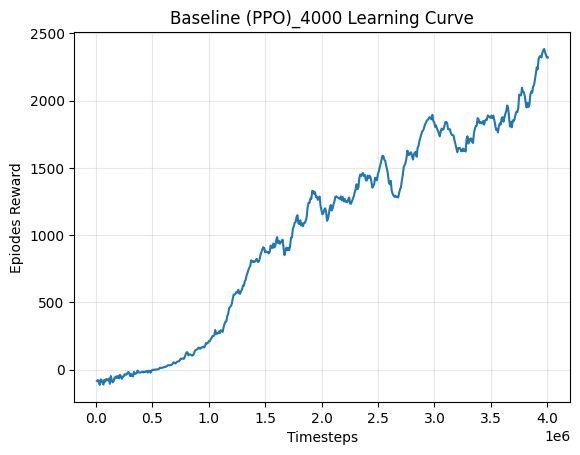

In [104]:
log_dir = "./graph/Baseline_4000/"
title = "Baseline (PPO)_4000"
learning_curve(log_dir, title)

### 3.2 Experiment B (one change):  
- Base on PPO, change `learning rate` within $1000,000$
- `learning rate = 0.0003`
- `learning rate = 0.0015`
- `learning rate = 0.003`

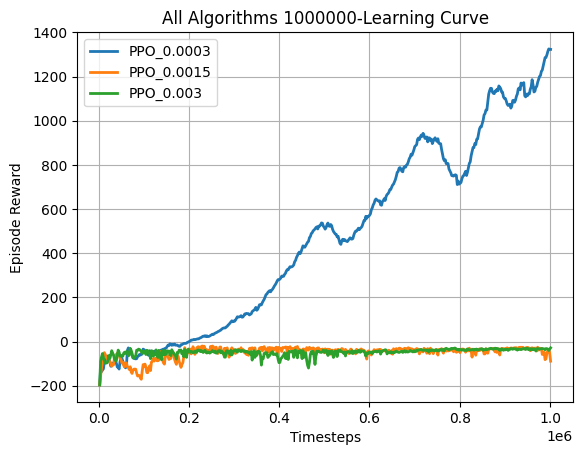

In [4]:
logs ={
    "PPO_0.0003": "./logs_experimentB/different_learning_rate/PPO_0.0003/",
    "PPO_0.0015": "./logs_experimentB/different_learning_rate/PPO_0.0015/",
    "PPO_0.003": "./logs_experimentB/different_learning_rate/PPO_0.003/",
}
learning_curve_all_model(logs,1000_000)

### 3.3 Experiment C: 
- Within `total_steps = 500,000` and `total_steps = 1000,000`, benchmark in PPO, A2C, DDPG, SAC (with default hyperparameters)
- seed = 42

In [3]:
def learning_curve_all_model(logs,total):

    for name, log in logs.items():
        ea = event_accumulator.EventAccumulator(log)
        ea.Reload()
        scalars = ea.Scalars("rollout/ep_rew_mean")
        steps = np.array([s.step for s in scalars])
        values = np.array([s.value for s in scalars])
        plt.plot(steps,values, label=name, linewidth=2)
    plt.title(f"All Algorithms {total}-Learning Curve")
    plt.xlabel("Timesteps")
    plt.ylabel("Episode Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

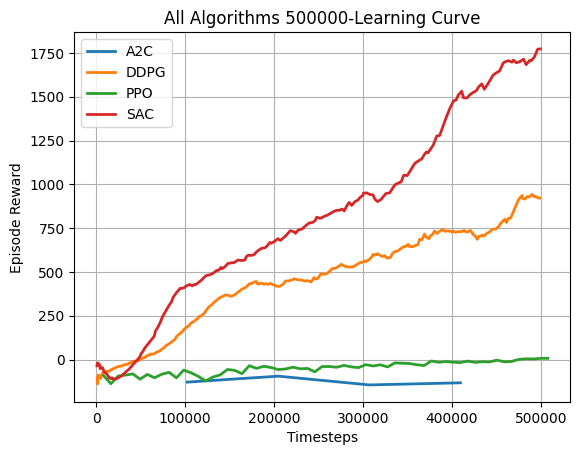

In [106]:
logs ={
    "A2C": "./graph/A2C_500/",
    "DDPG": "./graph/DDPG_500/",
    "PPO": "./graph/PPO_500",
    "SAC": "./graph/SAC_500/"
}
learning_curve_all_model(logs,500_000)

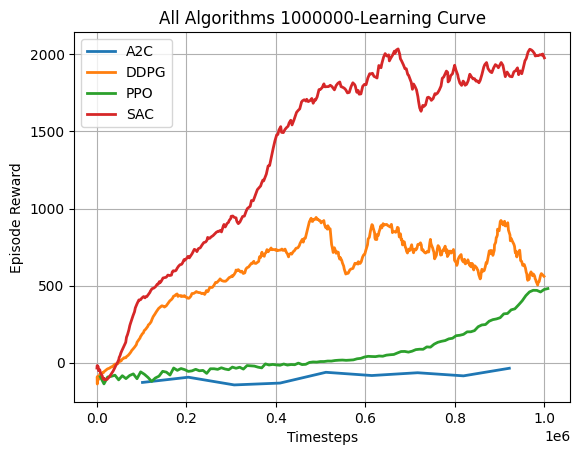

In [107]:
logs ={
    "A2C": "./graph/A2C_1000/",
    "DDPG": "./graph/DDPG_1000/",
    "PPO": "./graph/PPO_1000",
    "SAC": "./graph/SAC_1000/"
}
learning_curve_all_model(logs,1000_000)

**What changed between experiments:**
- Learning rate
- total_steps
- different algorithms
- different hyperparameters

## 4. Results

### 4.0 Evaluation Metrics  
1. Mean ± confidence interval episode return over 50 episodes : *shows how good it on average, how certain it is*.</br> Equation: $ci = \bar{x} ± 1.96 * \frac{s}{\sqrt{n}}$ 
3. Median and Interquartile Range (IQR) over 50 episodes: *how stable/consistent it is*


### 4.1 Baseline Result (Experiment A)

In [1]:
import gymnasium as gym
import os
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO


In [129]:
def evaluate_model(model, env_name = "Ant-v5", n_episodes = 50):

    ## predict model to get rewards for each episodes
    env = gym.make(env_name)
    rewards = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False 
        total_reward = 0

        while not done: 
            action, _ = model.predict(obs, deterministic=True)
            obs,reward,terminated,truncated,_ = env.step(action)
            total_reward += reward
            done = terminated or truncated 

        rewards.append(total_reward)

    ## start evaluate
    print("\n=========Evaluation==========\n")
    data = np.array(rewards)
    ## confidence_interval
    ci = 1.96 * data.std(ddof=1) / np.sqrt(len(data)) ## P(-1.96< Z < 1.96) = 0.95 | large sample n > 30 
    print(f"Mean ± 95% CI: {data.mean():.2f} ± {ci:.2f}")

    ## IQR Interquartile Range IQR = Q3 - Q1
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    print(f"Median: {np.median(data):.2f}")
    print(f"IQR: [{q1:.2f}, {q3:.2f}] = {(q3-q1):.2f}")
    print(f"Min/Max: {data.min():.2f} / {data.max():.2f}")
    env.close()

#### 4.1.1 PPO_baseline with Timesteps = 1000_000


In [130]:
model = PPO.load("baseline_1000")
evaluate_model(model)


=========Evaluation==========

Mean ± 95% CI: 1611.49 ± 164.75
Median: 1895.56
IQR: [1490.26, 1960.83] = 470.57
Min/Max: 57.39 / 2123.14


#### 4.1.2 PPO_baseline with Timesteps = 4000_000  


In [32]:
model = PPO.load("baseline_4000")
evaluate_model(model)


=========Evaluation==========

Mean ± 95% CI: 3010.34 ± 94.43
Median: 3090.15
IQR: [3039.04, 3146.55] = 107.51
Min/Max: 1525.04 / 3256.43


### 4.3 Benchmark Results (Experiment C)

#### 4.3.0 Utility Function

In [2]:
def evaluate_all_models(algorithms, models, env_name="Ant-v5", n_eval_episodes=50):
    evaluation_env = gym.make(env_name)
    results = {}

    for alg, model in zip(algorithms, models):
        print(f"\nEvaluating {alg} ....")
        
        rewards = []
        for _ in range(n_eval_episodes):
            obs, _ = evaluation_env.reset()
            done = False 
            total_reward = 0

            while not done: 
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = evaluation_env.step(action)
                total_reward += reward
                done = terminated or truncated 

            rewards.append(total_reward)

        # Statistical Calculations
        data = np.array(rewards)
        mean_reward = data.mean()
        std_reward = data.std(ddof=1)
        
        # 95% Confidence Interval
        ci = 1.96 * std_reward / np.sqrt(len(data))
        
        # IQR Calculation
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)

        # Store all metrics in the results dictionary
        results[alg] = {
            'mean': data.mean(),
            'ci': ci,
            'median': np.median(data),
            'q1': q1,
            'q3': q3,
            'iqr': q3 - q1,
            'min': data.min(),
            'max': data.max()}
    evaluation_env.close()
    return results

#### 4.3.1 Timesteps = 500_000  
```
============================================================
TRAINING SUMMARY
============================================================
Environment: Ant-v5
Training timesteps: 500_000
Algorithms trained: A2C, DDPG, PPO, SAC

Final Performance Over 50 episodes:
Algorithm    | Mean ± 95% CI      |     Median |        IQR |            Min / Max
--------------------------------------------------------------------------------
A2C          |   525.84 ±  95.34  |     494.94 |     652.54 |        20.3 / 1027.1
DDPG         |   851.07 ± 209.72  |     665.02 |     858.37 |         6.4 / 2610.6
PPO          |   225.66 ±  76.65  |      97.32 |     157.50 |          2.3 / 865.5
SAC          |  2439.23 ± 105.08  |    2543.31 |     141.48 |       858.2 / 2791.8

All models have been trained and evaluated successfully!

```

In [115]:
algorithms = ['A2C', 'DDPG', 'PPO', 'SAC']
models = []
print("Loading trained models...")

model_a2c_loaded = A2C.load("a2c_ant_500000_42")
models.append(model_a2c_loaded)

# Load DDPG model
model_ddpg_loaded = DDPG.load("ddpg_ant_500000_42")
models.append(model_ddpg_loaded)

# Load PPO model
model_ppo_loaded = PPO.load("ppo_ant_500000_42")
models.append(model_ppo_loaded)


# Load SAC model
model_sac_loaded = SAC.load("sac_ant_500000_42")
models.append(model_sac_loaded)

print("\nAll models successfully! ✅")

Loading trained models...

All models successfully! ✅


In [116]:
eval_results = evaluate_all_models(algorithms, models)


Evaluating A2C ....

Evaluating DDPG ....

Evaluating PPO ....

Evaluating SAC ....


In [119]:
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Environment: Ant-v5")
print(f"Training timesteps: 500_000")
print(f"Algorithms trained: {', '.join(algorithms)}")
print("\nFinal Performance Over 50 episodes:")

print(f"{'Algorithm':<12} | {'Mean ± 95% CI':<18} | {'Median':>10} | {'IQR':>10} | {'Min / Max':>20}")
print("-" * 80)
for alg in algorithms:
    res = eval_results[alg]
    stats = f"{res['mean']:>8.2f} ± {res['ci']:>6.2f}"
    range_str = f"{res['min']:.1f} / {res['max']:.1f}"
    
    print(f"{alg:<12} | {stats:<18} | {res['median']:>10.2f} | {res['iqr']:>10.2f} | {range_str:>20}")

print("\nAll models have been trained and evaluated successfully!")


TRAINING SUMMARY
Environment: Ant-v5
Training timesteps: 500_000
Algorithms trained: A2C, DDPG, PPO, SAC

Final Performance Over 50 episodes:
Algorithm    | Mean ± 95% CI      |     Median |        IQR |            Min / Max
--------------------------------------------------------------------------------
A2C          |   620.54 ±  96.41  |     795.37 |     611.08 |         12.2 / 997.0
DDPG         |   663.42 ± 158.56  |     559.58 |     737.13 |        10.6 / 2470.9
PPO          |   186.95 ±  64.46  |     102.88 |     148.96 |        12.4 / 1005.3
SAC          |  2313.22 ± 176.37  |    2571.28 |     127.58 |        13.3 / 2711.7

All models have been trained and evaluated successfully!


#### 4.3.1 Timesteps = 1000_000 

```
============================================================
TRAINING SUMMARY
============================================================
Environment: Ant-v5
Training timesteps: 1000_000
Algorithms trained: A2C, DDPG, PPO, SAC

Final Performance Over 50 episodes:
Algorithm    | Mean ± 95% CI      |     Median |        IQR |            Min / Max
--------------------------------------------------------------------------------
A2C          |     0.75 ±   5.07  |       2.77 |      17.86 |         -63.9 / 46.6
DDPG         |   700.89 ± 224.99  |     466.89 |    1249.22 |      -610.2 / 2851.8
PPO          |  1606.10 ±  48.73  |    1644.17 |      69.05 |       783.3 / 1755.6
SAC          |  2135.68 ± 270.08  |    2662.48 |    1756.69 |       233.1 / 3184.0

All models have been trained and evaluated successfully!


```

In [120]:
algorithms = ['A2C', 'DDPG', 'PPO', 'SAC']
models = []
print("Loading trained models...")

model_a2c_loaded = A2C.load("a2c_ant_1000000_42")
models.append(model_a2c_loaded)

# Load DDPG model
model_ddpg_loaded = DDPG.load("ddpg_ant_1000000_42")
models.append(model_ddpg_loaded)

# Load PPO model
model_ppo_loaded = PPO.load("ppo_ant_1000000_42")
models.append(model_ppo_loaded)


# Load SAC model
model_sac_loaded = SAC.load("sac_ant_1000000_42")
models.append(model_sac_loaded)

print("\nAll models successfully! ✅")

Loading trained models...

All models successfully! ✅


In [121]:
eval_results = evaluate_all_models(algorithms, models)


Evaluating A2C ....

Evaluating DDPG ....

Evaluating PPO ....

Evaluating SAC ....


In [122]:
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Environment: Ant-v5")
print(f"Training timesteps: 1000_000")
print(f"Algorithms trained: {', '.join(algorithms)}")
print("\nFinal Performance Over 50 episodes:")

print(f"{'Algorithm':<12} | {'Mean ± 95% CI':<18} | {'Median':>10} | {'IQR':>10} | {'Min / Max':>20}")
print("-" * 80)
for alg in algorithms:
    res = eval_results[alg]
    stats = f"{res['mean']:>8.2f} ± {res['ci']:>6.2f}"
    range_str = f"{res['min']:.1f} / {res['max']:.1f}"
    
    print(f"{alg:<12} | {stats:<18} | {res['median']:>10.2f} | {res['iqr']:>10.2f} | {range_str:>20}")

print("\nAll models have been trained and evaluated successfully!")


TRAINING SUMMARY
Environment: Ant-v5
Training timesteps: 1000_000
Algorithms trained: A2C, DDPG, PPO, SAC

Final Performance Over 50 episodes:
Algorithm    | Mean ± 95% CI      |     Median |        IQR |            Min / Max
--------------------------------------------------------------------------------
A2C          |     7.55 ±   6.34  |       5.35 |      31.09 |         -51.0 / 62.7
DDPG         |   557.95 ± 206.52  |     448.98 |     773.87 |      -715.8 / 2952.1
PPO          |  1619.38 ±  25.79  |    1628.01 |      84.90 |      1149.4 / 1755.7
SAC          |  2088.32 ± 303.43  |    2887.76 |    2011.26 |       106.7 / 3140.3

All models have been trained and evaluated successfully!


## 5. Analysis

### 5.1 What Worked: 

### 5.2 What did not work:


### 5.3 Why you think the results look this way:


### 5.4 Any reward-design, observation-design or hyperparameter lessons:
